In [10]:
"""
Step 1: Test Connection to Rekrute.ma
This step verifies we can connect to the job portal without errors.
"""
import requests
from bs4 import BeautifulSoup

# Browser headers to avoid being blocked
user_agent_headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

base_url = "https://www.rekrute.com/offres.html"

# Test the connection
response = requests.get(base_url, headers=user_agent_headers, timeout=10)
print(f"Connection Status: {response.status_code}")
print(f"{'SUCCESS' if response.status_code == 200 else '❌ FAILED'}")

Connection Status: 200
SUCCESS


In [11]:
"""
Step 2: Parse the First Page
Let's examine the HTML structure to understand how job listings are organized.
"""
import requests
from bs4 import BeautifulSoup
import pandas as pd

user_agent_headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

base_url = "https://www.rekrute.com/offres.html"
response = requests.get(base_url, headers=user_agent_headers, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")

# Display a preview of the HTML structure
print("HTML Structure Preview:")
print("=" * 50)
print(soup.prettify()[:2000])

HTML Structure Preview:
<!DOCTYPE html>
<html ng-app="app" xmlns:og="http://ogp.me/ns#">
 <head>
  <meta content="ReKrute.com" name="application-name"/>
  <meta content="https://www.rekrute.com" name="msapplication-starturl"/>
  <meta content="#fff" name="theme-color"/>
  <meta content="True" name="HandheldFriendly">
   <meta content="320" name="MobileOptimized"/>
   <meta content="width=device-width, target-densitydpi=160dpi, initial-scale=1.0" name="viewport"/>
   <link href="https://www.rekrute.com/images/favRK.jpg" rel="icon" type="image/png"/>
   <title>
    Emploi Maroc  - offres d’emploi
   </title>
   <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
   <meta content="fr-fr" http-equiv="Content-Language"/>
   <meta content="Retrouvez sur ReKrute toutes les annonces et offres d’emploi au Maroc des multinationales et grands comptes marocains  à destination des cadres et professions intermédiaires.  Affinez votre recherche d’emploi grâce au moteur de recherche p

In [12]:
"""
Step 3: Extract Job Listings from First Page
Find and count all job offers on the page.
"""

# Find all job offer containers
job_listings = soup.find_all("li", class_="post-id")

# Display statistics
print(f"\n Job Listings Found: {len(job_listings)}")
print("=" * 50)
print(f"\n Sample of First Job Offer:")
print(job_listings[0])


 Job Listings Found: 10

 Sample of First Job Offer:
<li class="post-id" id="182727">
<div>
<div class="col-sm-2 col-xs-12" style="text-align: center; padding-right: 3px;
    padding-left: 2px;">
<a href="/btechnologie-emploi-recrutement-345673.html">
<img alt="BTechnologie" class="photo" src="/rekrute/file/jobOfferLogo/jobOfferId/182727" style="max-width: 100%;" title="BTechnologie" width="115"/>
</a>
<!--------------------------SCORE matching--------------------------------------->
<div style="margin-bottom: 20px;">
<a class="btn btn-primary lancer4KRK" href="/offre-emploi-ingenieure-methode-qos-mobile-2g3g4g5g-hf-recrutement-btechnologie-rabat-182727.html?#matching4K" target="_blank">  Lancer 4K  </a>
</div>
<!--------------------------Fin Score Matching----------------------------------->
</div>
<div class="col-sm-10 col-xs-12">
<div class="section">
<h2 style="width:90%">
<a class="titreJob" href="/offre-emploi-ingenieure-methode-qos-mobile-2g3g4g5g-hf-recrutement-btechnologie-ra

In [13]:
"""
Step 4: Parse Job Details from Single Page
Extract job information: title, link, sector, function, experience, and contract type.
"""

job_records = []

for job_listing in job_listings:
    # Extract job title
    job_title_element = job_listing.find("a", class_="titreJob")
    job_title = job_title_element.text.strip() if job_title_element else "N/A"
    
    # Extract job link
    job_link = "https://www.rekrute.com" + job_title_element["href"] if job_title_element else "N/A"
    
    # Extract detailed information
    info_items = job_listing.find_all("li")
    
    # Initialize job details
    sector = "N/A"
    function = "N/A"
    experience = "N/A"
    contract_type = "N/A"
    
    # Parse information items
    for info_item in info_items:
        item_text = info_item.text.strip()
        
        if "Secteur" in item_text:
            sector = info_item.find("a").text.strip()
        elif "Fonction" in item_text:
            function = info_item.find("a").text.strip()
        elif "Expérience" in item_text:
            experience = info_item.find("a").text.strip()
        elif "contrat proposé" in item_text:
            contract_type = info_item.find("a").text.strip()
    
    # Add job record
    job_records.append({
        "Title": job_title,
        "Sector": sector,
        "Function": function,
        "Experience": experience,
        "Contract": contract_type,
        "Link": job_link
    })

# Convert to DataFrame
jobs_df = pd.DataFrame(job_records)

print(f"\n Successfully extracted {len(jobs_df)} job offers")
print("\n Sample Data:")
print(jobs_df.head())


 Successfully extracted 10 job offers

 Sample Data:
                                               Title             Sector  \
0  Ingénieur(e) Méthode QOS  mobile 2G/3G/4G/5G (...            Telecom   
1  Dessinateur Projeteur Revit / Modélisation 3D ...  BTP / Génie Civil   
2        Responsable Commercial | Casablanca (Maroc)    Agroalimentaire   
3  Conseiller Client (F/H) - Service client - Rab...    Centre d'appels   
4  Conseiller Client (F/H) - Télévente - Rabat - ...    Centre d'appels   

                       Function                 Experience Contract  \
0             Télécom / Réseaux      Confirmé (5 à 10 ans)      CDI   
1     Travaux / Chantiers / BTP  Intermédiaire (3 à 5 ans)      CDI   
2   Commercial / Vente / Export  Intermédiaire (3 à 5 ans)      CDI   
3  Centre d'appels (métiers de)           Débutant (-1 an)    Autre   
4  Centre d'appels (métiers de)           Débutant (-1 an)    Autre   

                                                Link  
0  https://ww

In [14]:
"""
Step 5: Scrape Multiple Pages
Loop through 10 pages and collect all job offers.
IMPORTANT: We pause between requests to be respectful to the server.
"""
import time

all_job_records = []
total_pages = 10

print(f" Starting to scrape {total_pages} pages...")
print("=" * 50)

for page_number in range(1, total_pages + 1):
    # Build page URL
    page_url = f"https://www.rekrute.com/offres.html?p={page_number}"
    
    # Request page
    response = requests.get(page_url, headers=user_agent_headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    
    # Find all job listings
    job_listings = soup.find_all("li", class_="post-id")
    
    # Process each job
    for job_listing in job_listings:
        job_title_element = job_listing.find("a", class_="titreJob")
        job_title = job_title_element.text.strip() if job_title_element else "N/A"
        
        job_link = "https://www.rekrute.com" + job_title_element["href"] if job_title_element else "N/A"
        
        info_items = job_listing.find_all("li")
        sector = function = experience = contract_type = "N/A"
        
        for info_item in info_items:
            item_text = info_item.text.strip()
            if "Secteur" in item_text:
                sector = info_item.find("a").text.strip()
            elif "Fonction" in item_text:
                function = info_item.find("a").text.strip()
            elif "Expérience" in item_text:
                experience = info_item.find("a").text.strip()
            elif "contrat proposé" in item_text:
                contract_type = info_item.find("a").text.strip()
        
        all_job_records.append({
            "Title": job_title,
            "Sector": sector,
            "Function": function,
            "Experience": experience,
            "Contract": contract_type,
            "Link": job_link
        })
    
    # Status update
    print(f" Page {page_number:2d} → {len(job_listings):3d} job offers collected")
    
    # Respectful pause between requests
    time.sleep(1)

# Create final DataFrame
jobs_df = pd.DataFrame(all_job_records)

print("\n" + "=" * 50)
print(f"TOTAL COLLECTED: {len(jobs_df)} job offers")
print("\n Sample Data:")
print(jobs_df.head())

 Starting to scrape 10 pages...


 Page  1 →  10 job offers collected
 Page  2 →  10 job offers collected
 Page  3 →  10 job offers collected
 Page  4 →  10 job offers collected
 Page  5 →  10 job offers collected
 Page  6 →  10 job offers collected
 Page  7 →  10 job offers collected
 Page  8 →  10 job offers collected
 Page  9 →  10 job offers collected
 Page 10 →  10 job offers collected

TOTAL COLLECTED: 100 job offers

 Sample Data:
                                               Title             Sector  \
0  Ingénieur(e) Méthode QOS  mobile 2G/3G/4G/5G (...            Telecom   
1  Dessinateur Projeteur Revit / Modélisation 3D ...  BTP / Génie Civil   
2        Responsable Commercial | Casablanca (Maroc)    Agroalimentaire   
3  Conseiller Client (F/H) - Service client - Rab...    Centre d'appels   
4  Conseiller Client (F/H) - Télévente - Rabat - ...    Centre d'appels   

                       Function                 Experience Contract  \
0             Télécom / Réseaux      Confirmé (5 à 10 ans)      CDI   

In [15]:
"""
Step 6: Save Data to CSV
Export the collected data and check data quality.
"""

# Save to CSV file
output_file = "offres_rekrute.csv"
jobs_df.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"Data saved to: {output_file}")

# Data quality check
print("\n DATA QUALITY REPORT:")
print("=" * 50)
print(f"Shape: {jobs_df.shape[0]} rows × {jobs_df.shape[1]} columns")
print(f"\nColumn Information:")
print(jobs_df.info())
print(f"\n Missing Values Count:")
print(jobs_df.isnull().sum())

Data saved to: offres_rekrute.csv

 DATA QUALITY REPORT:
Shape: 100 rows × 6 columns

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       100 non-null    object
 1   Sector      100 non-null    object
 2   Function    100 non-null    object
 3   Experience  100 non-null    object
 4   Contract    100 non-null    object
 5   Link        100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB
None

 Missing Values Count:
Title         0
Sector        0
Function      0
Experience    0
Contract      0
Link          0
dtype: int64


In [16]:
"""
Step 7: Analyze Job Market Trends
Get statistical summaries of key job market attributes.
"""

print(" JOB MARKET ANALYSIS")
print("=" * 50)

print("\n TOP 10 SECTORS:")
print(jobs_df["Sector"].value_counts().head(10))

print("\n" + "-" * 50)
print("\n TOP 10 FUNCTIONS:")
print(jobs_df["Function"].value_counts().head(10))

print("\n" + "-" * 50)
print("\n CONTRACT TYPES:")
print(jobs_df["Contract"].value_counts())

print("\n" + "-" * 50)
print("\n EXPERIENCE REQUIREMENTS:")
print(jobs_df["Experience"].value_counts())

 JOB MARKET ANALYSIS

 TOP 10 SECTORS:
Sector
Centre d'appels                32
Automobile / Motos / Cycles    15
Informatique                    9
Assurance / Courtage            7
Autres services                 7
Agroalimentaire                 3
Comptabilité / Audit            3
Telecom                         2
BTP / Génie Civil               2
Conseil / Etudes                2
Name: count, dtype: int64

--------------------------------------------------

 TOP 10 FUNCTIONS:
Function
Centre d'appels (métiers de)                     32
Informatique / Electronique                      11
Commercial / Vente / Export                       7
Administration des ventes / SAV                   7
Gestion projet / Etudes / R&D                     5
Production / Qualité / Sécurité / Maintenance     5
Achats / Supply Chain                             3
Gestion / Comptabilité / Finance                  3
Marketing                                         3
Télécom / Réseaux                      

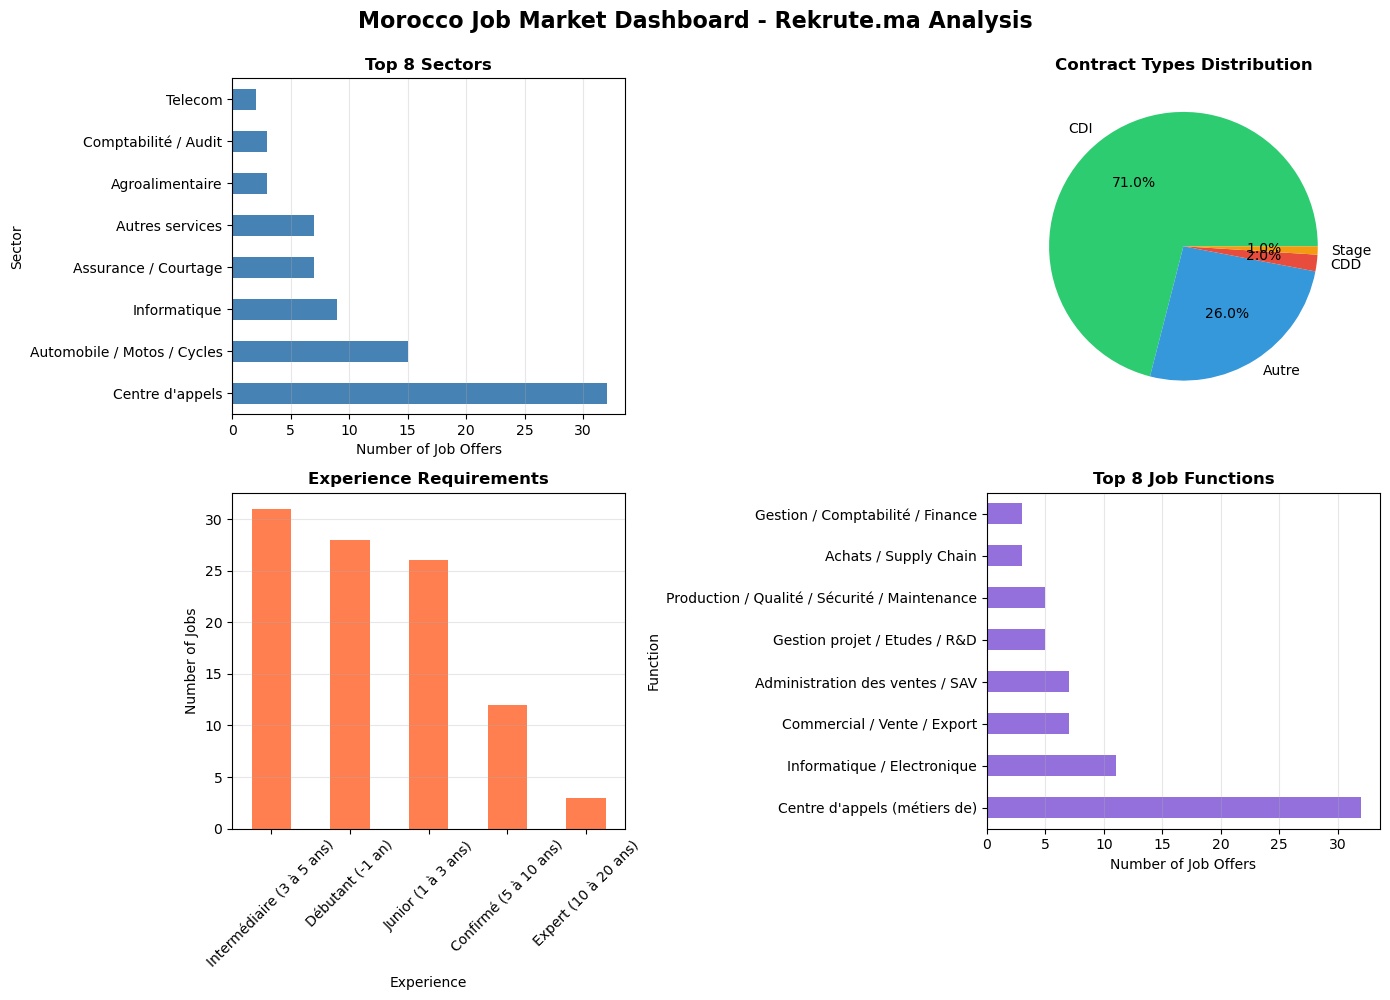

Visualization saved as: job_market_analysis.png


In [17]:
"""
Step 8: Create Visualization Dashboard
Generate a comprehensive 4-panel visualization of job market insights.
"""
import matplotlib.pyplot as plt

# Create figure with subplots
figure, chart_axes = plt.subplots(2, 2, figsize=(14, 10))
figure.suptitle("Morocco Job Market Dashboard - Rekrute.ma Analysis", 
               fontsize=16, fontweight="bold", y=0.995)

# Panel 1: Top Sectors (Horizontal Bar Chart)
jobs_df["Sector"].value_counts().head(8).plot(
    kind="barh", 
    ax=chart_axes[0, 0], 
    color="steelblue"
)
chart_axes[0, 0].set_title("Top 8 Sectors", fontweight="bold")
chart_axes[0, 0].set_xlabel("Number of Job Offers")
chart_axes[0, 0].grid(axis="x", alpha=0.3)

# Panel 2: Contract Types (Pie Chart)
jobs_df["Contract"].value_counts().plot(
    kind="pie", 
    ax=chart_axes[0, 1], 
    autopct="%1.1f%%",
    colors=["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]
)
chart_axes[0, 1].set_title("Contract Types Distribution", fontweight="bold")
chart_axes[0, 1].set_ylabel("")

# Panel 3: Experience Requirements (Vertical Bar Chart)
jobs_df["Experience"].value_counts().plot(
    kind="bar", 
    ax=chart_axes[1, 0], 
    color="coral"
)
chart_axes[1, 0].set_title("Experience Requirements", fontweight="bold")
chart_axes[1, 0].set_ylabel("Number of Jobs")
chart_axes[1, 0].tick_params(axis="x", rotation=45)
chart_axes[1, 0].grid(axis="y", alpha=0.3)

# Panel 4: Top Functions (Horizontal Bar Chart)
jobs_df["Function"].value_counts().head(8).plot(
    kind="barh", 
    ax=chart_axes[1, 1], 
    color="mediumpurple"
)
chart_axes[1, 1].set_title("Top 8 Job Functions", fontweight="bold")
chart_axes[1, 1].set_xlabel("Number of Job Offers")
chart_axes[1, 1].grid(axis="x", alpha=0.3)

# Apply layout and save
plt.tight_layout()
output_image = "job_market_analysis.png"
plt.savefig(output_image, dpi=150, bbox_inches="tight")
plt.show()

print(f"Visualization saved as: {output_image}")

In [18]:
"""
Step 9: Store Data in SQLite Database
Create a database for persistent storage and complex queries.
"""
import sqlite3

# Create database connection
database_name = "job_market_morocco.db"
database_connection = sqlite3.connect(database_name)

# Store DataFrame in database
jobs_df.to_sql("job_offers", database_connection, if_exists="replace", index=False)
print(f" Database created: {database_name}")

# Verify data was stored
print("\n DATABASE VERIFICATION:")
print("=" * 50)

# Query: Top sectors
query_sectors = """
SELECT Sector, COUNT(*) as count
FROM job_offers
WHERE Sector != 'N/A'
GROUP BY Sector
ORDER BY count DESC
LIMIT 5
"""

sector_results = pd.read_sql(query_sectors, database_connection)
print("\n🏭 Top 5 Sectors in Database:")
print(sector_results.to_string(index=False))

# Close connection
database_connection.close()
print(f"\n Database connection closed")

 Database created: job_market_morocco.db

 DATABASE VERIFICATION:

🏭 Top 5 Sectors in Database:
                     Sector  count
            Centre d'appels     32
Automobile / Motos / Cycles     15
               Informatique      9
            Autres services      7
       Assurance / Courtage      7

 Database connection closed
